In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("billion_file_changes/billionaire_individual_2026.csv")
print(df.head())


df["self_made"].sample(n=5)

   rank      person_name gender   age        country iso3 wb_country_name  \
0     1        Elon Musk      M  54.0  United States  USA   United States   
1     2       Larry Page      M  53.0  United States  USA   United States   
2     3       Jeff Bezos      M  62.0  United States  USA   United States   
3     4      Sergey Brin      M  52.0  United States  USA   United States   
4     5  Mark Zuckerberg      M  41.0  United States  USA   United States   

        state       city  net_worth_usd_m  ...  wealth_gdp_ratio_pct  \
0       Texas     Austin        800629.06  ...              2.784704   
1  California  Palo Alto        260898.20  ...              0.907442   
2     Florida      Miami        248778.91  ...              0.865289   
3  California  Los Altos        240743.24  ...              0.837340   
4  California  Palo Alto        216089.31  ...              0.751590   

  wealth_per_citizen_usd wealth_country_share_pct sector_dominance_score  \
0              2354.0229    

1306     True
1355     True
567     False
1138    False
2491     True
Name: self_made, dtype: bool

In [22]:
columns = df.columns
print(columns)

rows = df.shape[0]
print(rows)


df_clean = df[[
    "person_name",
    "age",
    "net_worth_usd_m",
    "primary_industry",
    "industries",
    "country",
    "self_made",
    # "city",
    "gender"
]]

df_clean = df_clean.rename(columns={
    "person_name": "name",
    "net_worth_usd_m": "net_worth_million_usd",
    "primary_industry": "industry"
})



print(df_clean.head())
df_clean.to_csv("billionaire_individual_needed_columns.csv", index=False)

Index(['rank', 'person_name', 'gender', 'age', 'country', 'iso3',
       'wb_country_name', 'state', 'city', 'net_worth_usd_m', 'net_worth_usd',
       'source_of_wealth', 'industries', 'primary_industry', 'self_made',
       'wealth_gdp_ratio_pct', 'wealth_per_citizen_usd',
       'wealth_country_share_pct', 'sector_dominance_score', 'gdp_usd',
       'population', 'gdp_year', 'forbes_uri', 'scrape_timestamp',
       'birth_year'],
      dtype='object')
3384
              name   age  net_worth_million_usd    industry  industries  \
0        Elon Musk  54.0              800629.06  Technology  Technology   
1       Larry Page  53.0              260898.20  Technology  Technology   
2       Jeff Bezos  62.0              248778.91  Technology  Technology   
3      Sergey Brin  52.0              240743.24  Technology  Technology   
4  Mark Zuckerberg  41.0              216089.31  Technology  Technology   

         country  self_made gender  
0  United States       True      M  
1  United S

In [23]:
df_needed = pd.read_csv("billion_file_changes/billionaire_individual_needed_columns.csv")

print(f"number of columns: {len(df_needed.columns)}, name of columns: {df_needed.columns}")  

df_needed.head()

number of columns: 8, name of columns: Index(['name', 'age', 'net_worth_million_usd', 'industry', 'industries',
       'country', 'self_made', 'gender'],
      dtype='object')


,name,age,net_worth_million_usd,industry,industries,country,self_made,gender
0,Elon Musk,54.0,800629.06,Technology,Technology,United States,True,M
1,Larry Page,53.0,260898.20,Technology,Technology,United States,True,M
2,Jeff Bezos,62.0,248778.91,Technology,Technology,United States,True,M
3,Sergey Brin,52.0,240743.24,Technology,Technology,United States,True,M
4,Mark Zuckerberg,41.0,216089.31,Technology,Technology,United States,True,M


Average age: 65.3


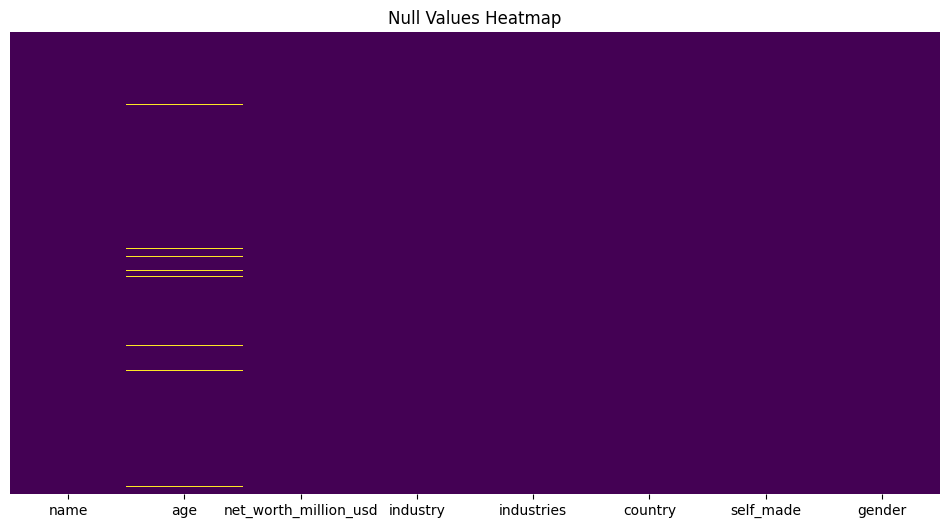

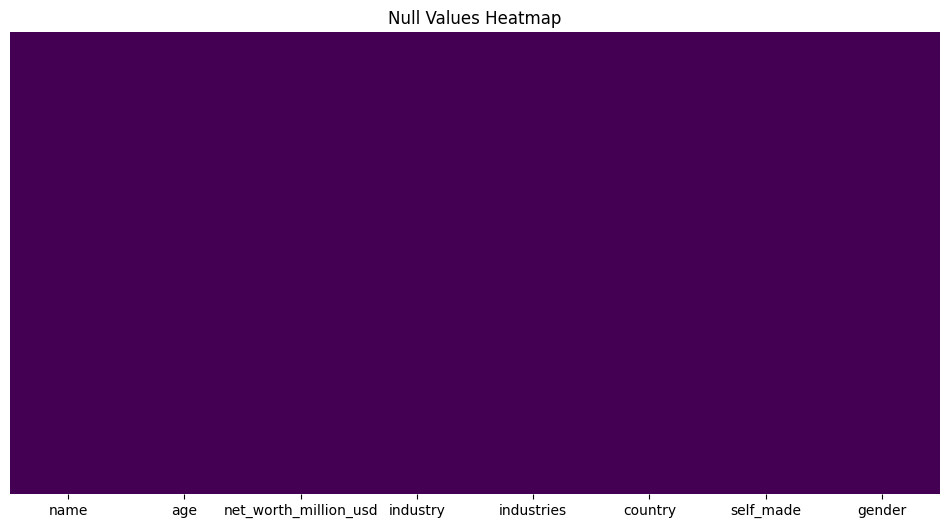

np.int64(0)

In [24]:
avg_age = round(df_needed["age"].mean() ,1)

print(f"Average age: {avg_age}")

plt.figure(figsize=(12, 6))
sns.heatmap(df_needed.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Null Values Heatmap")
plt.show()

df_needed["age"] = df_needed["age"].fillna(df_needed["age"].mean())

plt.figure(figsize=(12, 6))
sns.heatmap(df_needed.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Null Values Heatmap")
plt.show()


df_needed["age"].isnull().sum()


In [26]:
df_needed.head()

df_needed = df_needed[[
    "name",
    "age",
    "net_worth_million_usd",
    # "primary_industry",
    "industries",
    "country",
    "self_made",
    # "city",
    "gender"
]]


df_needed.sample(n=5)

,name,age,net_worth_million_usd,industries,country,self_made,gender
123,Michael Platt,58.0,20901.00,Finance & Investments,United Kingdom,True,M
2230,Casey Foyt,43.0,1848.60,Sports,United States,False,F
2790,Huang Chulong,67.0,1364.27,Real Estate,Canada,True,M
1702,Nicola Leibinger-Kammueller,66.0,2432.97,Manufacturing,Germany,False,F
819,Mangal Prabhat Lodha,70.0,5092.63,Real Estate,India,True,M


In [27]:
# now let's remove billionaires with net worth less than 1 billion USD

df_needed.info()

df_needed = df_needed[df_needed["net_worth_million_usd"] >= 1000]

df_needed.info()


3384-3374

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3384 entries, 0 to 3383
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   3384 non-null   object 
 1   age                    3384 non-null   float64
 2   net_worth_million_usd  3384 non-null   float64
 3   industries             3384 non-null   object 
 4   country                3384 non-null   object 
 5   self_made              3384 non-null   bool   
 6   gender                 3384 non-null   object 
dtypes: bool(1), float64(2), object(4)
memory usage: 162.1+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 3374 entries, 0 to 3373
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   3374 non-null   object 
 1   age                    3374 non-null   float64
 2   net_worth_million_usd  3374 non-null   float64
 3

10

In [28]:


df_needed["age"] = df_needed["age"].astype(int)

# df_needed["net_worth_million_usd"] = df_needed["net_worth_million_usd"].astype(int)

df_needed.info()

df_needed.sample(n=5)

<class 'pandas.core.frame.DataFrame'>
Index: 3374 entries, 0 to 3373
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   3374 non-null   object 
 1   age                    3374 non-null   int64  
 2   net_worth_million_usd  3374 non-null   float64
 3   industries             3374 non-null   object 
 4   country                3374 non-null   object 
 5   self_made              3374 non-null   bool   
 6   gender                 3374 non-null   object 
dtypes: bool(1), float64(1), int64(1), object(4)
memory usage: 187.8+ KB


,name,age,net_worth_million_usd,industries,country,self_made,gender
3247,Zachary Stern,44,1083.45,Food & Beverage,United States,False,M
1055,Angelo Koo,60,4001.96,Finance & Investments,Taiwan,False,M
3288,Luigi Cremonini & family,87,1060.72,Food & Beverage,Italy,True,M
2150,Sandro Veronesi & family,66,1919.49,Fashion & Retail,Italy,True,M
3113,Chad Richison,55,1163.66,Technology,United States,True,M


In [29]:
df_needed.to_csv("billionaire_individual_perfect.csv", index=False)


In [30]:
print(df_needed["name"].sample(n=30)          ) 

1260                        Warren Stephens
2997                            Michael Kum
851                            Peter Cancro
698                             Rick Caruso
2882                             Ge Tairong
2200                Itzhak Ezratti & family
2796                           Nikesh Arora
875                    Gail Miller & family
2941                       Lauren Leichtman
916                           Scott Kapnick
1635                 Mario Germano Giuliani
2398                             Lai Jianfa
3276                              Petr Bely
419                              Leo KoGuan
1207                             C.C. Leung
3174                       Igor Kudryashkin
2008                          Nihat Ozdemir
682                        Mikhail Lomtadze
1772                     Wu Lanlan & family
499                          Michael Milken
1495    Alfredo Egydio Arruda Villela Filho
3124                             Li Xuechun
1228                         Geo